## Layer-wise analysis of no-LoRA runs (Apertus vs Llama)
This notebook aggregates runs named as `{model}_no_lora_long_form_layer{layer}_seed{seed}` and compares performance across layers.

In [16]:
import re
from typing import Dict, List, Optional

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import wandb

from matplotlib.patches import Patch


sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

api = wandb.Api()
ENTITY = "ethz-lsai-25"
PROJECT = "hallucination-probes"
RUN_PATH = f"{ENTITY}/{PROJECT}"

In [17]:
MODELS = ["apertus", "llama"]
LAYERS = [4, 10, 16, 20, 24, 26, 28, 30]
SEEDS = [42, 43, 44]
TEST_MODELS = ["apertus", "llama"]
METRIC_FAMILIES = ["all", "span", "span_max"]
METRICS = ["auc", "f1", "acc", "recall_at_0.1_fpr"]

RUN_NAME_PATTERN = re.compile(
    r"^(apertus|llama)_no_lora_long_form_layer(4|10|16|20|24|26|28|30)_seed(42|43|44)$"
)


def _extract_probe_id(run) -> Optional[str]:
    name = run.name or ""
    if RUN_NAME_PATTERN.match(name):
        return name

    cfg = run.config or {}

    if isinstance(cfg.get("probe_config"), dict):
        nested = cfg["probe_config"].get("probe_id")
        if isinstance(nested, str) and RUN_NAME_PATTERN.match(nested):
            return nested

    for key in ["probe_config.probe_id", "probe_config/probe_id", "probe_id"]:
        value = cfg.get(key)
        if isinstance(value, str) and RUN_NAME_PATTERN.match(value):
            return value

    return None


def _safe_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


rows: List[Dict] = []
for run in api.runs(RUN_PATH):
    probe_id = _extract_probe_id(run)
    if probe_id is None:
        continue

    match = RUN_NAME_PATTERN.match(probe_id)
    if match is None:
        continue

    model, layer, seed = match.groups()
    summary = run.summary._json_dict

    row = {
        "run_id": run.id,
        "run_name": run.name,
        "probe_id": probe_id,
        "state": run.state,
        "created_at": pd.to_datetime(run.created_at, utc=True),
        "model": model,
        "layer": int(layer),
        "seed": int(seed),
    }

    for test_model in TEST_MODELS:
        for family in METRIC_FAMILIES:
            for metric in METRICS:
                key = f"train/longfact_test_{test_model}/{family}_{metric}"
                row[key] = _safe_float(summary.get(key))

    rows.append(row)

df_runs = pd.DataFrame(rows)
if df_runs.empty:
    raise ValueError(
        "No matching runs found. Expected names like: model_no_lora_long_form_layerX_seedY"
    )

# keep one run per (model, layer, seed): prefer finished runs, then latest by creation time
state_rank = {"finished": 0, "running": 1, "queued": 2, "failed": 3, "crashed": 4}
df_runs["_state_rank"] = df_runs["state"].map(state_rank).fillna(99)
df_runs = (
    df_runs.sort_values(["_state_rank", "created_at"], ascending=[True, False])
    .drop_duplicates(["model", "layer", "seed"], keep="first")
    .drop(columns=["_state_rank"])
    .sort_values(["model", "layer", "seed"])
    .reset_index(drop=True)
)

print(f"Collected {len(df_runs)} runs.")
df_runs.head()

Collected 48 runs.


,run_id,run_name,probe_id,state,created_at,model,layer,seed,train/longfact_test_apertus/all_auc,train/longfact_test_apertus/all_f1,...,train/longfact_test_llama/all_acc,train/longfact_test_llama/all_recall_at_0.1_fpr,train/longfact_test_llama/span_auc,train/longfact_test_llama/span_f1,train/longfact_test_llama/span_acc,train/longfact_test_llama/span_recall_at_0.1_fpr,train/longfact_test_llama/span_max_auc,train/longfact_test_llama/span_max_f1,train/longfact_test_llama/span_max_acc,train/longfact_test_llama/span_max_recall_at_0.1_fpr
0,f1osa4x3,apertus_no_lora_long_form_layer4_seed42,apertus_no_lora_long_form_layer4_seed42,finished,2026-03-02 14:54:28+00:00,apertus,4,42,0.824844,0.240945,...,None,0.487495,0.777610,0.449453,None,0.441819,0.811477,0.578584,None,0.527496
1,k9210t28,apertus_no_lora_long_form_layer4_seed43,apertus_no_lora_long_form_layer4_seed43,finished,2026-03-02 14:54:28+00:00,apertus,4,43,0.836407,0.244405,...,None,0.504856,0.776085,0.443318,None,0.441520,0.807824,0.573342,None,0.513374
2,4dw0ohsb,apertus_no_lora_long_form_layer4_seed44,apertus_no_lora_long_form_layer4_seed44,finished,2026-03-02 14:54:28+00:00,apertus,4,44,0.830202,0.243102,...,None,0.498985,0.777284,0.453365,None,0.443299,0.807481,0.573777,None,0.517528
3,2msk68xv,apertus_no_lora_long_form_layer10_seed42,apertus_no_lora_long_form_layer10_seed42,finished,2026-03-02 14:54:28+00:00,apertus,10,42,0.834979,0.271590,...,None,0.515747,0.813953,0.493873,None,0.503486,0.857475,0.639567,None,0.596943
4,ennpfi5c,apertus_no_lora_long_form_layer10_seed43,apertus_no_lora_long_form_layer10_seed43,finished,2026-03-02 14:55:28+00:00,apertus,10,43,0.830068,0.280137,...,None,0.518234,0.818641,0.545862,None,0.511309,0.857727,0.650889,None,0.601263


In [18]:
expected = len(MODELS) * len(LAYERS) * len(SEEDS)
print(f"Expected combinations: {expected}")
print(f"Available combinations: {len(df_runs)}")

coverage = (
    df_runs.groupby(["model", "layer"]).size().rename("num_seeds").reset_index()
)
coverage.pivot(index="layer", columns="model", values="num_seeds").reindex(LAYERS)

Expected combinations: 48
Available combinations: 48


model,apertus,llama
layer,,
4,3,3
10,3,3
16,3,3
20,3,3
24,3,3
26,3,3
28,3,3
30,3,3


In [19]:
# convert wide metrics into tidy long format for plotting
metric_columns = [
    f"train/longfact_test_{test_model}/{family}_{metric}"
    for test_model in TEST_MODELS
    for family in METRIC_FAMILIES
    for metric in METRICS
]

df_long = df_runs.melt(
    id_vars=["run_id", "probe_id", "state", "created_at", "model", "layer", "seed"],
    value_vars=metric_columns,
    var_name="metric_key",
    value_name="value",
)

parsed = df_long["metric_key"].str.extract(
    r"train/longfact_test_(apertus|llama)/(all|span|span_max)_(auc|f1|acc|recall_at_0\.1_fpr)"
)
parsed.columns = ["test_model", "metric_family", "metric"]

df_long = pd.concat([df_long, parsed], axis=1)
df_long = df_long.dropna(subset=["value", "test_model", "metric_family", "metric"]).copy()
df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")
df_long = df_long.dropna(subset=["value"]).reset_index(drop=True)

df_long.head()

,run_id,probe_id,state,created_at,model,layer,seed,metric_key,value,test_model,metric_family,metric
0,f1osa4x3,apertus_no_lora_long_form_layer4_seed42,finished,2026-03-02 14:54:28+00:00,apertus,4,42,train/longfact_test_apertus/all_auc,0.824844,apertus,all,auc
1,k9210t28,apertus_no_lora_long_form_layer4_seed43,finished,2026-03-02 14:54:28+00:00,apertus,4,43,train/longfact_test_apertus/all_auc,0.836407,apertus,all,auc
2,4dw0ohsb,apertus_no_lora_long_form_layer4_seed44,finished,2026-03-02 14:54:28+00:00,apertus,4,44,train/longfact_test_apertus/all_auc,0.830202,apertus,all,auc
3,2msk68xv,apertus_no_lora_long_form_layer10_seed42,finished,2026-03-02 14:54:28+00:00,apertus,10,42,train/longfact_test_apertus/all_auc,0.834979,apertus,all,auc
4,ennpfi5c,apertus_no_lora_long_form_layer10_seed43,finished,2026-03-02 14:55:28+00:00,apertus,10,43,train/longfact_test_apertus/all_auc,0.830068,apertus,all,auc


In [20]:
COLORS = {"apertus": "#E07B39", "llama": "#3B82C4"}
METRIC_LABELS = {"auc": "AUC", "f1": "F1"}
MODEL_DISPLAY_NAMES = {
    "apertus": "Apertus-8B-Instruct-2509",
    "llama": "Llama-3.1-8B-Instruct",
}


def plot_layer_metrics(df, metric_family="all", test_model="apertus"):
    subset = df[(df["metric_family"] == metric_family) & (df["test_model"] == test_model)].copy()
    if subset.empty:
        raise ValueError(f"No rows for metric_family={metric_family}, test_model={test_model}.")

    agg = (
        subset.groupby(["model", "layer", "metric"])
        .agg(mean=("value", "mean"), std=("value", "std"), n=("value", "size"))
        .reset_index()
    )
    agg["std"] = agg["std"].fillna(0.0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), sharex=True)

    for ax, metric in zip(axes, METRIC_LABELS.keys()):
        metric_df = agg[agg["metric"] == metric]

        for model in MODELS:
            line_df = metric_df[metric_df["model"] == model].sort_values("layer")
            if line_df.empty:
                continue

            x = line_df["layer"].to_numpy()
            y = line_df["mean"].to_numpy()
            yerr = line_df["std"].to_numpy()

            ax.plot(x, y, marker="o", linewidth=2.2, label=MODEL_DISPLAY_NAMES[model], color=COLORS[model])
            ax.fill_between(x, y - yerr, y + yerr, alpha=0.18, color=COLORS[model])

        ax.set_title(METRIC_LABELS[metric], fontsize=12)
        ax.set_xlabel("Probe training layer (activation layer)")
        ax.set_xticks(LAYERS)
        ax.grid(True, alpha=0.25, linestyle=":")
        ax.spines[["top", "right"]].set_visible(False)

        if metric == "auc":
            ax.set_ylabel("Score")

    fig.suptitle(
        f"Hallucination detection probe performance across Transformer layers | Evaluated on {MODEL_DISPLAY_NAMES[test_model]}",
        fontsize=13,
        y=1.06,
    )

    handles, labels = axes[0].get_legend_handles_labels()
    title_handle = Patch(visible=False)

    legend = fig.legend(
        [title_handle] + handles,
        ["Training set:"] + labels,
        loc="upper center",
        ncol=len(labels) + 1,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02),
        columnspacing=1.2,
        handlelength=2,
        handletextpad=0.4,
    )
    texts = legend.get_texts()
    texts[0].set_fontweight("bold")

    # Add gray subscript with probe parameters
    param_text = "Probe config: learning rate = 1e-3, no layernorm, no LoRA, probe dtype = bfloat16"
    fig.text(0.5, 0.01, param_text, ha="center", fontsize=9, color="#6B7280", style="italic")

    fig.tight_layout(rect=(0, 0.04, 1, 1))
    plt.show()


In [21]:
# Example alternatives:
# plot_layer_metrics(df_long, metric_family="all", test_model="llama")
# plot_layer_metrics(df_long, metric_family="span", test_model="apertus")
# plot_layer_metrics(df_long, metric_family="span_max", test_model="llama")

In [22]:
# Fetch final training loss from each run's W&B summary
import numpy as np

loss_rows = []
for _, r in df_runs.iterrows():
    run_obj = api.run(f"{RUN_PATH}/{r['run_id']}")
    final_loss = run_obj.summary.get("train/loss")
    if final_loss is None:
        hist = run_obj.history(keys=["train/loss"], pandas=True)
        if not hist.empty:
            final_loss = hist["train/loss"].dropna().iloc[-1]
    loss_rows.append({
        "model": r["model"],
        "layer": r["layer"],
        "seed": r["seed"],
        "final_loss": float(final_loss) if final_loss is not None else np.nan,
    })

df_loss = pd.DataFrame(loss_rows)
print(f"Fetched final loss for {df_loss['final_loss'].notna().sum()}/{len(df_loss)} runs")
df_loss.head()

Fetched final loss for 48/48 runs


,model,layer,seed,final_loss
0,apertus,4,42,0.301314
1,apertus,4,43,0.248202
2,apertus,4,44,0.148470
3,apertus,10,42,0.118864
4,apertus,10,43,0.289212


In [30]:
def plot_auc_r01_and_loss(df, df_loss, metric_family="all", test_model="apertus"):
    # --- AUC & R@0.1 data ---
    eval_subset = df[
        (df["metric_family"] == metric_family)
        & (df["test_model"] == test_model)
        & (df["metric"].isin(["auc", "recall_at_0.1_fpr"]))
    ].copy()
    if eval_subset.empty:
        raise ValueError(f"No eval rows for metric_family={metric_family}, test_model={test_model}.")

    auc_agg = (
        eval_subset[eval_subset["metric"] == "auc"]
        .groupby(["model", "layer"])["value"]
        .agg(["mean", "std"]).reset_index()
    )
    auc_agg["std"] = auc_agg["std"].fillna(0.0)

    r01_agg = (
        eval_subset[eval_subset["metric"] == "recall_at_0.1_fpr"]
        .groupby(["model", "layer"])["value"]
        .agg(["mean", "std"]).reset_index()
    )
    r01_agg["std"] = r01_agg["std"].fillna(0.0)

    # --- Loss data ---
    loss_agg = (
        df_loss.groupby(["model", "layer"])["final_loss"]
        .agg(["mean", "std"]).reset_index()
    )
    loss_agg["std"] = loss_agg["std"].fillna(0.0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True)

    panels = [
        (axes[0], auc_agg, "AUC", "Score"),
        (axes[1], r01_agg, "Recall at 0.1 False Positive Rate", "Score"),
        (axes[2], loss_agg, "Final training loss", "Cross-entropy loss (log scale)"),
    ]

    for ax, agg, title, ylabel in panels:
        for model in MODELS:
            sub = agg[agg["model"] == model].sort_values("layer")
            if sub.empty:
                continue

            x = sub["layer"].to_numpy()
            y = sub["mean"].to_numpy()
            yerr = sub["std"].to_numpy()

            ax.plot(x, y, marker="o", linewidth=2.2, label=MODEL_DISPLAY_NAMES[model], color=COLORS[model])
            ax.fill_between(x, y - yerr, y + yerr, alpha=0.18, color=COLORS[model])

        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Probe training layer (activation layer)")
        ax.set_ylabel(ylabel)
        ax.set_xticks(LAYERS)
        ax.grid(True, alpha=0.25, linestyle=":")
        ax.spines[["top", "right"]].set_visible(False)
        if title == "Final training loss":
            ax.set_yscale("log")

    fig.suptitle(
        f"Baseline probe performance and training instability across layers on {MODEL_DISPLAY_NAMES[test_model]} test set",
        fontsize=13,
        y=1.06,
    )

    handles, labels = axes[0].get_legend_handles_labels()
    title_handle = Patch(visible=False)

    legend = fig.legend(
        [title_handle] + handles,
        ["Training set:"] + labels,
        loc="upper center",
        ncol=len(labels) + 1,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02),
        columnspacing=1.2,
        handlelength=2,
        handletextpad=0.4,
    )
    texts = legend.get_texts()
    texts[0].set_fontweight("bold")

    param_text = "Probe config: learning rate = 1e-3, no layernorm, no LoRA, probe dtype = bfloat16, averaged accross 3 random seeds"
    fig.text(0.5, 0.01, param_text, ha="center", fontsize=9, color="#6B7280", style="italic")

    fig.tight_layout(rect=(0, 0.04, 1, 1))
    plt.show()

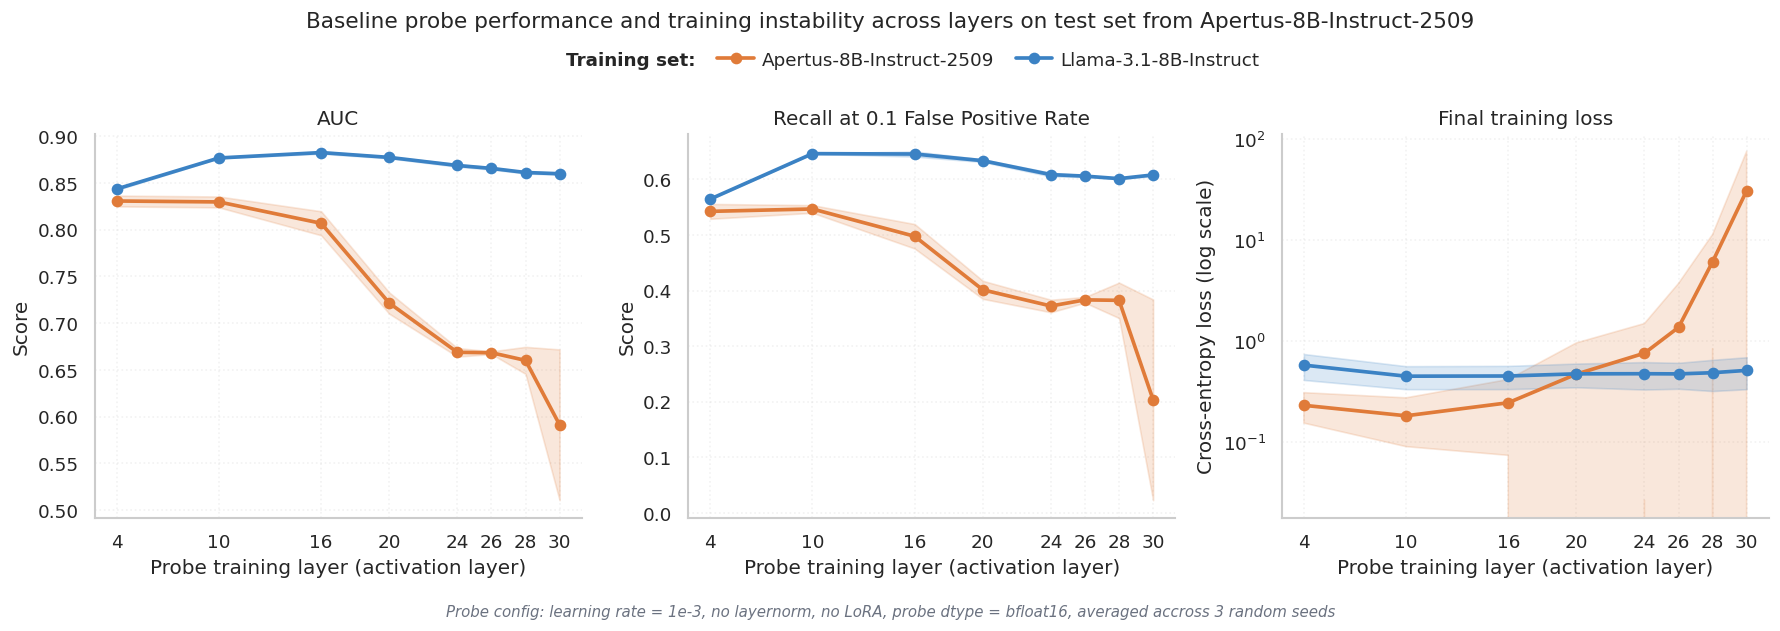

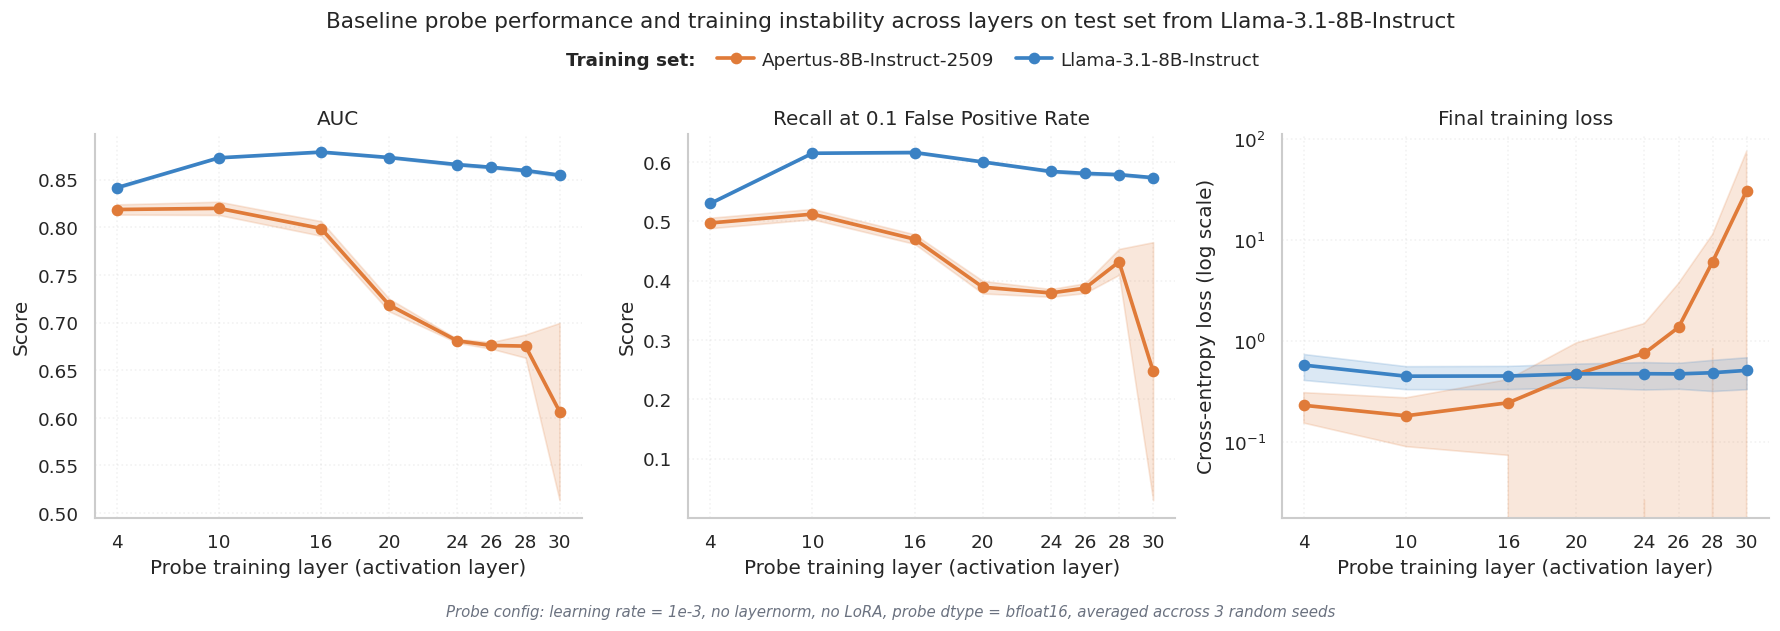

In [29]:
plot_auc_r01_and_loss(df_long, df_loss, metric_family="all", test_model="apertus")
plot_auc_r01_and_loss(df_long, df_loss, metric_family="all", test_model="llama")